# Nacimiento Wildfire Burned Area Mapping (2023)
### Post-Fire Severity Assessment using Sentinel-2 NBR/dNBR Analysis

**Author:** Constanza Morales Gajardo  
**Date:** July 2026  
**Location:** Nacimiento, Biobío Region, Chile

## 1. Introduction

This notebook maps burned area severity from the February 2023 "Santa Ana" megafire in Nacimiento, Biobío Region, Chile, using Sentinel-2 spectral analysis.

**Study area:** Fire-affected zone within Nacimiento commune (boundary to be defined based on burned extent, not the administrative/urban boundary used in previous flood risk analysis).

**Fire event:** Started February 2, 2023 — contained approximately February 14, 2023.

**Period analyzed:**
- Pre-fire: January 2023
- Post-fire: March 2023

**Data source:** Sentinel-2 Surface Reflectance (Copernicus/S2_SR_HARMONIZED), bands B8 (NIR) and B12 (SWIR).

**Method:** Normalized Burn Ratio (NBR) calculated pre- and post-fire, differenced (dNBR) and classified using USGS severity thresholds.

**Tools:** Google Earth Engine (Python API), geemap, Folium.

In [1]:
# Import required libraries
import ee
import geemap
import folium
import rasterio
import numpy as np
import geopandas as gpd

# Initialize Google Earth Engine
ee.Initialize(project='earth-engine-portfolio-498609')

print("Libraries imported and GEE initialized successfully.")

Libraries imported and GEE initialized successfully.


## 2. Study Area Definition

The study area is defined as a bounding box covering the fire-affected extent within Nacimiento commune, based on the February 2023 "Santa Ana" wildfire (~75% of communal area affected). This bounding box is used only to constrain the Sentinel-2 image search — the actual burned area extent will be derived from the dNBR classification later in this analysis, not imported from external sources.

In [2]:
# Define approximate bounding box for Nacimiento commune (fire-affected area)
# Extended west to better capture Cordillera de Nahuelbuta fire extent
nacimiento_bbox = ee.Geometry.Rectangle([
    -72.95,  # west (min longitude) - moved further west
    -37.65,  # south (min latitude)
    -72.55,  # east (max longitude)
    -37.40   # north (max latitude)
])

# Quick visual check on a basic map
Map = geemap.Map()
Map.centerObject(nacimiento_bbox, zoom=11)
Map.addLayer(nacimiento_bbox, {'color': 'red'}, 'Study Area Bounding Box')
Map

Map(center=[-37.52509880908124, -72.75000000000009], controls=(WidgetControl(options=['position', 'transparent…

## 3. Sentinel-2 Image Search

Searching Sentinel-2 Surface Reflectance imagery for pre-fire and post-fire periods, filtered by cloud coverage over the study area.

**Pre-fire period:** January 1–31, 2023
**Post-fire period:** April 1–30, 2023 (adjusted from initial March estimate — CONAF declared the fire contained on February 27, 2023, with residual activity reported until March 27; April allows sufficient margin for smoke clearance and fire extinction)

In [3]:
# Define date ranges
pre_fire_start = '2023-01-01'
pre_fire_end = '2023-01-31'
post_fire_start = '2023-04-01'
post_fire_end = '2023-04-30'

# Load Sentinel-2 Surface Reflectance collection, filtered by area and cloud cover
s2_collection = ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED') \
    .filterBounds(nacimiento_bbox) \
    .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 20))

# Pre-fire images
pre_fire_images = s2_collection.filterDate(pre_fire_start, pre_fire_end)
pre_fire_count = pre_fire_images.size().getInfo()

# Post-fire images
post_fire_images = s2_collection.filterDate(post_fire_start, post_fire_end)
post_fire_count = post_fire_images.size().getInfo()

print(f"Pre-fire images found (Jan 2023, <20% clouds): {pre_fire_count}")
print(f"Post-fire images found (Apr 2023, <20% clouds): {post_fire_count}")

Pre-fire images found (Jan 2023, <20% clouds): 11
Post-fire images found (Apr 2023, <20% clouds): 5


In [4]:
# Select the least cloudy image from each period
pre_fire_best = pre_fire_images.sort('CLOUDY_PIXEL_PERCENTAGE').first()
post_fire_best = post_fire_images.sort('CLOUDY_PIXEL_PERCENTAGE').first()

# Check acquisition dates and cloud percentage
pre_fire_date = pre_fire_best.get('PRODUCT_ID').getInfo()
pre_fire_clouds = pre_fire_best.get('CLOUDY_PIXEL_PERCENTAGE').getInfo()

post_fire_date = post_fire_best.get('PRODUCT_ID').getInfo()
post_fire_clouds = post_fire_best.get('CLOUDY_PIXEL_PERCENTAGE').getInfo()

print(f"Pre-fire image: {pre_fire_date}")
print(f"Pre-fire cloud coverage: {pre_fire_clouds:.2f}%")
print()
print(f"Post-fire image: {post_fire_date}")
print(f"Post-fire cloud coverage: {post_fire_clouds:.2f}%")

Pre-fire image: S2A_MSIL2A_20230128T143721_N0509_R096_T18HYD_20230128T192752
Pre-fire cloud coverage: 0.00%

Post-fire image: S2B_MSIL2A_20230403T143729_N0509_R096_T18HYD_20230403T190421
Post-fire cloud coverage: 0.00%


In [5]:
# Visualization parameters for true color (RGB)
true_color_params = {
    'bands': ['B4', 'B3', 'B2'],  # Red, Green, Blue
    'min': 0,
    'max': 3000
}

# Add both images to the map for visual inspection
Map = geemap.Map()
Map.centerObject(nacimiento_bbox, zoom=11)
Map.addLayer(pre_fire_best.clip(nacimiento_bbox), true_color_params, 'Pre-Fire (Jan 28, 2023)')
Map.addLayer(post_fire_best.clip(nacimiento_bbox), true_color_params, 'Post-Fire (Apr 3, 2023)')
Map.addLayerControl()
Map

Map(center=[-37.52509880908124, -72.75000000000009], controls=(WidgetControl(options=['position', 'transparent…

In [6]:
# Instead of a single image, mosaic all tiles covering the bounding box for a narrow date window
# This ensures full spatial coverage even when the study area spans multiple Sentinel-2 tiles

pre_fire_mosaic = s2_collection.filterDate('2023-01-25', '2023-01-31').mosaic()
post_fire_mosaic = s2_collection.filterDate('2023-04-01', '2023-04-07').mosaic()

print("Pre-fire and post-fire mosaics created.")

Pre-fire and post-fire mosaics created.


In [7]:
# Visual check: does the mosaic now cover the full bounding box?
true_color_params = {
    'bands': ['B4', 'B3', 'B2'],
    'min': 0,
    'max': 3000
}

Map = geemap.Map()
Map.centerObject(nacimiento_bbox, zoom=10)
Map.addLayer(nacimiento_bbox, {'color': 'red'}, 'Bounding Box', opacity=0.3)
Map.addLayer(pre_fire_mosaic.clip(nacimiento_bbox), true_color_params, 'Pre-Fire Mosaic (Jan 2023)')
Map.addLayer(post_fire_mosaic.clip(nacimiento_bbox), true_color_params, 'Post-Fire Mosaic (Apr 2023)')
Map.addLayerControl()
Map

Map(center=[-37.525098809080006, -72.75000000000011], controls=(WidgetControl(options=['position', 'transparen…

In [8]:
# Load Nacimiento commune boundary from FAO GAUL Level 2
gaul_level2 = ee.FeatureCollection('FAO/GAUL/2015/level2')
nacimiento_boundary = gaul_level2.filter(
    ee.Filter.And(
        ee.Filter.eq('ADM0_NAME', 'Chile'),
        ee.Filter.eq('ADM2_NAME', 'Nacimiento')
    )
)

# Check that we found exactly one feature
print(f"Features found: {nacimiento_boundary.size().getInfo()}")

Features found: 0


In [9]:
# Debug: list all ADM2 names in Chile containing similar text, to find exact spelling
chile_communes = gaul_level2.filter(ee.Filter.eq('ADM0_NAME', 'Chile'))
all_names = chile_communes.aggregate_array('ADM2_NAME').getInfo()

# Search for anything similar to "Nacimiento"
matches = [name for name in all_names if 'acimiento' in name or 'Naci' in name]
print("Possible matches:", matches)

# If nothing found, print a sample of names to check the general format
print("\nSample of first 20 commune names in Chile:", sorted(all_names)[:20])

Possible matches: []

Sample of first 20 commune names in Chile: ['Aisen', 'Antartica Chilena', 'Antofagasta', 'Arauco', 'Arica', 'Biobio', 'Cachapoal', 'Capitan Prat', 'Cardenal Caro', 'Cauquenes', 'Cautin', 'Chacabuco', 'Chañaral', 'Chiloe', 'Choapa', 'Colchagua', 'Concepcion', 'Copiapo', 'Cordillera', 'Coyhaique']


In [10]:
import fiona

# List all layers available inside the geopackage
gpkg_path = '../data/raw/gadm41_CHL.gpkg'
layers = fiona.listlayers(gpkg_path)
print("Layers found in geopackage:", layers)

Layers found in geopackage: ['ADM_ADM_0', 'ADM_ADM_1', 'ADM_ADM_2', 'ADM_ADM_3']


In [11]:
# Load the commune-level layer (ADM_ADM_3) and filter for Nacimiento
communes = gpd.read_file(gpkg_path, layer='ADM_ADM_3')

# Search for Nacimiento (checking the correct column name for commune names)
nacimiento_gdf = communes[communes['NAME_3'] == 'Nacimiento']

print(f"Features found: {len(nacimiento_gdf)}")
print(nacimiento_gdf[['NAME_1', 'NAME_2', 'NAME_3']] if len(nacimiento_gdf) > 0 else "Not found - checking column names...")
print("\nColumns available:", communes.columns.tolist())

Features found: 1
     NAME_1   NAME_2      NAME_3
77  Bío-Bío  Bío-Bío  Nacimiento

Columns available: ['GID_3', 'GID_0', 'COUNTRY', 'GID_1', 'NAME_1', 'NL_NAME_1', 'GID_2', 'NAME_2', 'NL_NAME_2', 'NAME_3', 'VARNAME_3', 'NL_NAME_3', 'TYPE_3', 'ENGTYPE_3', 'CC_3', 'HASC_3', 'geometry']


In [12]:
# Convert the GeoPandas geometry to Earth Engine format
nacimiento_geojson = nacimiento_gdf.__geo_interface__
nacimiento_boundary = ee.FeatureCollection(nacimiento_geojson)

# Visual check: commune boundary over the mosaic
Map = geemap.Map()
Map.centerObject(nacimiento_boundary, zoom=10)
Map.addLayer(post_fire_mosaic.clip(nacimiento_bbox), true_color_params, 'Post-Fire Mosaic (Apr 2023)')
Map.addLayer(nacimiento_boundary.style(color='yellow', fillColor='00000000', width=2), {}, 'Nacimiento Commune Boundary')
Map.addLayerControl()
Map

Map(center=[-37.48548152276885, -72.82353068056327], controls=(WidgetControl(options=['position', 'transparent…

In [13]:
# Use the real commune boundary instead of the approximate bounding box
s2_collection_v2 = ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED') \
    .filterBounds(nacimiento_boundary) \
    .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 20))

pre_fire_mosaic = s2_collection_v2.filterDate('2023-01-25', '2023-01-31').mosaic()
post_fire_mosaic = s2_collection_v2.filterDate('2023-04-01', '2023-04-07').mosaic()

print("Images filtered and clipped using the real commune boundary.")

# Visual check with full commune coverage
Map = geemap.Map()
Map.centerObject(nacimiento_boundary, zoom=10)
Map.addLayer(post_fire_mosaic.clip(nacimiento_boundary), true_color_params, 'Post-Fire Mosaic (Apr 2023)')
Map.addLayer(nacimiento_boundary.style(color='yellow', fillColor='00000000', width=2), {}, 'Nacimiento Commune Boundary')
Map.addLayerControl()
Map

Images filtered and clipped using the real commune boundary.


Map(center=[-37.48548152276885, -72.82353068056327], controls=(WidgetControl(options=['position', 'transparent…

## 4. NBR Calculation (Pre-Fire and Post-Fire)

The Normalized Burn Ratio (NBR) is calculated for both periods using the formula:

NBR = (NIR - SWIR) / (NIR + SWIR)

Where:
- NIR = Band 8 (Near-Infrared, 842 nm)
- SWIR = Band 12 (Short-Wave Infrared, 2190 nm)

Healthy vegetation reflects strongly in NIR and absorbs in SWIR, producing high NBR values. Burned areas show the opposite pattern (low NIR, high SWIR), producing low or negative NBR values.

In [14]:
# Calculate NBR for pre-fire and post-fire mosaics
# NBR = (NIR - SWIR) / (NIR + SWIR) = (B8 - B12) / (B8 + B12)

nbr_pre = pre_fire_mosaic.normalizedDifference(['B8', 'B12']).rename('NBR_pre')
nbr_post = post_fire_mosaic.normalizedDifference(['B8', 'B12']).rename('NBR_post')

# Clip both to the commune boundary
nbr_pre = nbr_pre.clip(nacimiento_boundary)
nbr_post = nbr_post.clip(nacimiento_boundary)

print("NBR calculated for both pre-fire and post-fire periods.")

NBR calculated for both pre-fire and post-fire periods.


In [15]:
# Visualization parameters for NBR (red = low/burned, green = high/healthy vegetation)
nbr_params = {
    'min': -0.5,
    'max': 1,
    'palette': ['red', 'orange', 'yellow', 'lightgreen', 'darkgreen']
}

Map = geemap.Map()
Map.centerObject(nacimiento_boundary, zoom=10)
Map.addLayer(nbr_pre, nbr_params, 'NBR Pre-Fire (Jan 2023)')
Map.addLayer(nbr_post, nbr_params, 'NBR Post-Fire (Apr 2023)')
Map.addLayer(nacimiento_boundary.style(color='black', fillColor='00000000', width=2), {}, 'Nacimiento Boundary')
Map.addLayerControl()
Map

Map(center=[-37.48548152276885, -72.82353068056327], controls=(WidgetControl(options=['position', 'transparent…

## 5. dNBR Calculation and Severity Classification

dNBR (delta NBR) is calculated as:

dNBR = NBR_pre - NBR_post

Higher dNBR values indicate greater vegetation loss / burn severity. The result is classified into severity categories using standard USGS thresholds.

In [16]:
# Calculate dNBR
dnbr = nbr_pre.subtract(nbr_post).rename('dNBR')

# Visualization with a palette highlighting severity gradient
dnbr_params = {
    'min': -0.5,
    'max': 1.3,
    'palette': ['blue', 'green', 'yellow', 'orange', 'red', 'darkred']
}

Map = geemap.Map()
Map.centerObject(nacimiento_boundary, zoom=10)
Map.addLayer(dnbr, dnbr_params, 'dNBR')
Map.addLayer(nacimiento_boundary.style(color='black', fillColor='00000000', width=2), {}, 'Nacimiento Boundary')
Map.addLayerControl()
Map

Map(center=[-37.48548152276892, -72.82353068056312], controls=(WidgetControl(options=['position', 'transparent…

## 6. Severity Classification (USGS Thresholds)

dNBR values are classified into standard severity categories:

| dNBR Range | Severity Class |
|---|---|
| < 0.1 | Unburned / Regrowth |
| 0.1 – 0.27 | Low Severity |
| 0.27 – 0.44 | Moderate-Low Severity |
| 0.44 – 0.66 | Moderate-High Severity |
| > 0.66 | High Severity |

In [17]:
# Classify dNBR into severity categories using USGS thresholds
severity = ee.Image(0) \
    .where(dnbr.lt(0.1), 1) \
    .where(dnbr.gte(0.1).And(dnbr.lt(0.27)), 2) \
    .where(dnbr.gte(0.27).And(dnbr.lt(0.44)), 3) \
    .where(dnbr.gte(0.44).And(dnbr.lt(0.66)), 4) \
    .where(dnbr.gte(0.66), 5) \
    .clip(nacimiento_boundary) \
    .rename('severity')

# Visualization with distinct colors per class
severity_params = {
    'min': 1,
    'max': 5,
    'palette': ['darkgreen', 'yellow', 'orange', 'red', 'darkred']
}

Map = geemap.Map()
Map.centerObject(nacimiento_boundary, zoom=10)
Map.addLayer(severity, severity_params, 'Burn Severity Classification')
Map.addLayer(nacimiento_boundary.style(color='black', fillColor='00000000', width=2), {}, 'Nacimiento Boundary')
Map.addLayerControl()
Map

Map(center=[-37.48548152276892, -72.82353068056312], controls=(WidgetControl(options=['position', 'transparent…

In [18]:
# Calculate area (in hectares) per severity class
pixel_area = ee.Image.pixelArea().divide(10000)  # convert m² to hectares

area_by_class = pixel_area.addBands(severity).reduceRegion(
    reducer=ee.Reducer.sum().group(groupField=1, groupName='class'),
    geometry=nacimiento_boundary,
    scale=10,
    maxPixels=1e9
)

# Print results with readable labels
class_labels = {
    1: 'Unburned / Regrowth',
    2: 'Low Severity',
    3: 'Moderate-Low Severity',
    4: 'Moderate-High Severity',
    5: 'High Severity'
}

results = area_by_class.getInfo()['groups']
print("Burned Area by Severity Class:\n")
total_ha = 0
for r in results:
    label = class_labels.get(r['class'], 'Unknown')
    ha = r['sum']
    total_ha += ha
    print(f"{label}: {ha:,.1f} ha")

print(f"\nTotal area analyzed: {total_ha:,.1f} ha")

Burned Area by Severity Class:

Unburned / Regrowth: 54,742.6 ha
Low Severity: 10,090.8 ha
Moderate-Low Severity: 7,799.6 ha
Moderate-High Severity: 7,652.0 ha
High Severity: 10,708.8 ha

Total area analyzed: 90,993.7 ha


In [19]:
# Legend dictionary matching our severity classes and colors
legend_dict = {
    'Unburned / Regrowth': 'darkgreen',
    'Low Severity': 'yellow',
    'Moderate-Low Severity': 'orange',
    'Moderate-High Severity': 'red',
    'High Severity': 'darkred'
}

Map = geemap.Map()
Map.centerObject(nacimiento_boundary, zoom=10)
Map.addLayer(severity, severity_params, 'Burn Severity Classification')
Map.addLayer(nacimiento_boundary.style(color='black', fillColor='00000000', width=2), {}, 'Nacimiento Boundary')
Map.add_legend(title='Burn Severity', legend_dict=legend_dict)
Map.addLayerControl()
Map

Map(center=[-37.48548152276885, -72.82353068056327], controls=(WidgetControl(options=['position', 'transparent…

In [20]:
# Export severity classification as a permanent GeoTIFF
geemap.ee_export_image(
    severity,
    filename='../data/processed/nacimiento_burn_severity.tif',
    scale=10,
    region=nacimiento_boundary.geometry(),
    file_per_band=False
)

Generating URL ...
Please wait ...
Data downloaded to c:\Users\const\Documents\gis_projects\nacimiento-wildfire-2023\data\processed\nacimiento_burn_severity.tif


In [21]:
# Export continuous dNBR as well (backup/reference layer)
# Using coarser resolution (20m) since this is a reference layer, not the final map
geemap.ee_export_image(
    dnbr,
    filename='../data/processed/nacimiento_dnbr.tif',
    scale=20,
    region=nacimiento_boundary.geometry(),
    file_per_band=False
)

Generating URL ...
Please wait ...
Data downloaded to c:\Users\const\Documents\gis_projects\nacimiento-wildfire-2023\data\processed\nacimiento_dnbr.tif


## 7. Final Interactive Map (Permanent)

Building a standalone HTML map using the exported GeoTIFF (burn severity classification), following the permanent-tile pattern: rasterio reads the GeoTIFF → Folium ImageOverlay renders it. This avoids the token-expiration issue of GEE-based tiles.

In [22]:
import rasterio
import numpy as np

# Load the exported severity GeoTIFF
with rasterio.open('../data/processed/nacimiento_burn_severity.tif') as src:
    severity_array = src.read(1)
    bounds = src.bounds
    print(f"Raster shape: {severity_array.shape}")
    print(f"Bounds: {bounds}")
    print(f"Unique values: {np.unique(severity_array)}")

Raster shape: (3948, 5298)
Bounds: BoundingBox(left=-73.07085167237852, bottom=-37.630427251766754, right=-72.594924234852, top=-37.27577237759637)
Unique values: [0 1 2 3 4 5]


In [23]:
# Map severity classes to RGBA colors (0 = transparent, outside boundary)
color_map = {
    0: (0, 0, 0, 0),           # transparent (outside boundary)
    1: (0, 100, 0, 180),       # darkgreen - Unburned/Regrowth
    2: (255, 255, 0, 180),     # yellow - Low Severity
    3: (255, 165, 0, 180),     # orange - Moderate-Low Severity
    4: (255, 0, 0, 180),       # red - Moderate-High Severity
    5: (139, 0, 0, 180)        # darkred - High Severity
}

# Build RGBA array
rgba = np.zeros((severity_array.shape[0], severity_array.shape[1], 4), dtype=np.uint8)
for value, color in color_map.items():
    mask = severity_array == value
    rgba[mask] = color

print(f"RGBA array created with shape: {rgba.shape}")

RGBA array created with shape: (3948, 5298, 4)


Map saved successfully.



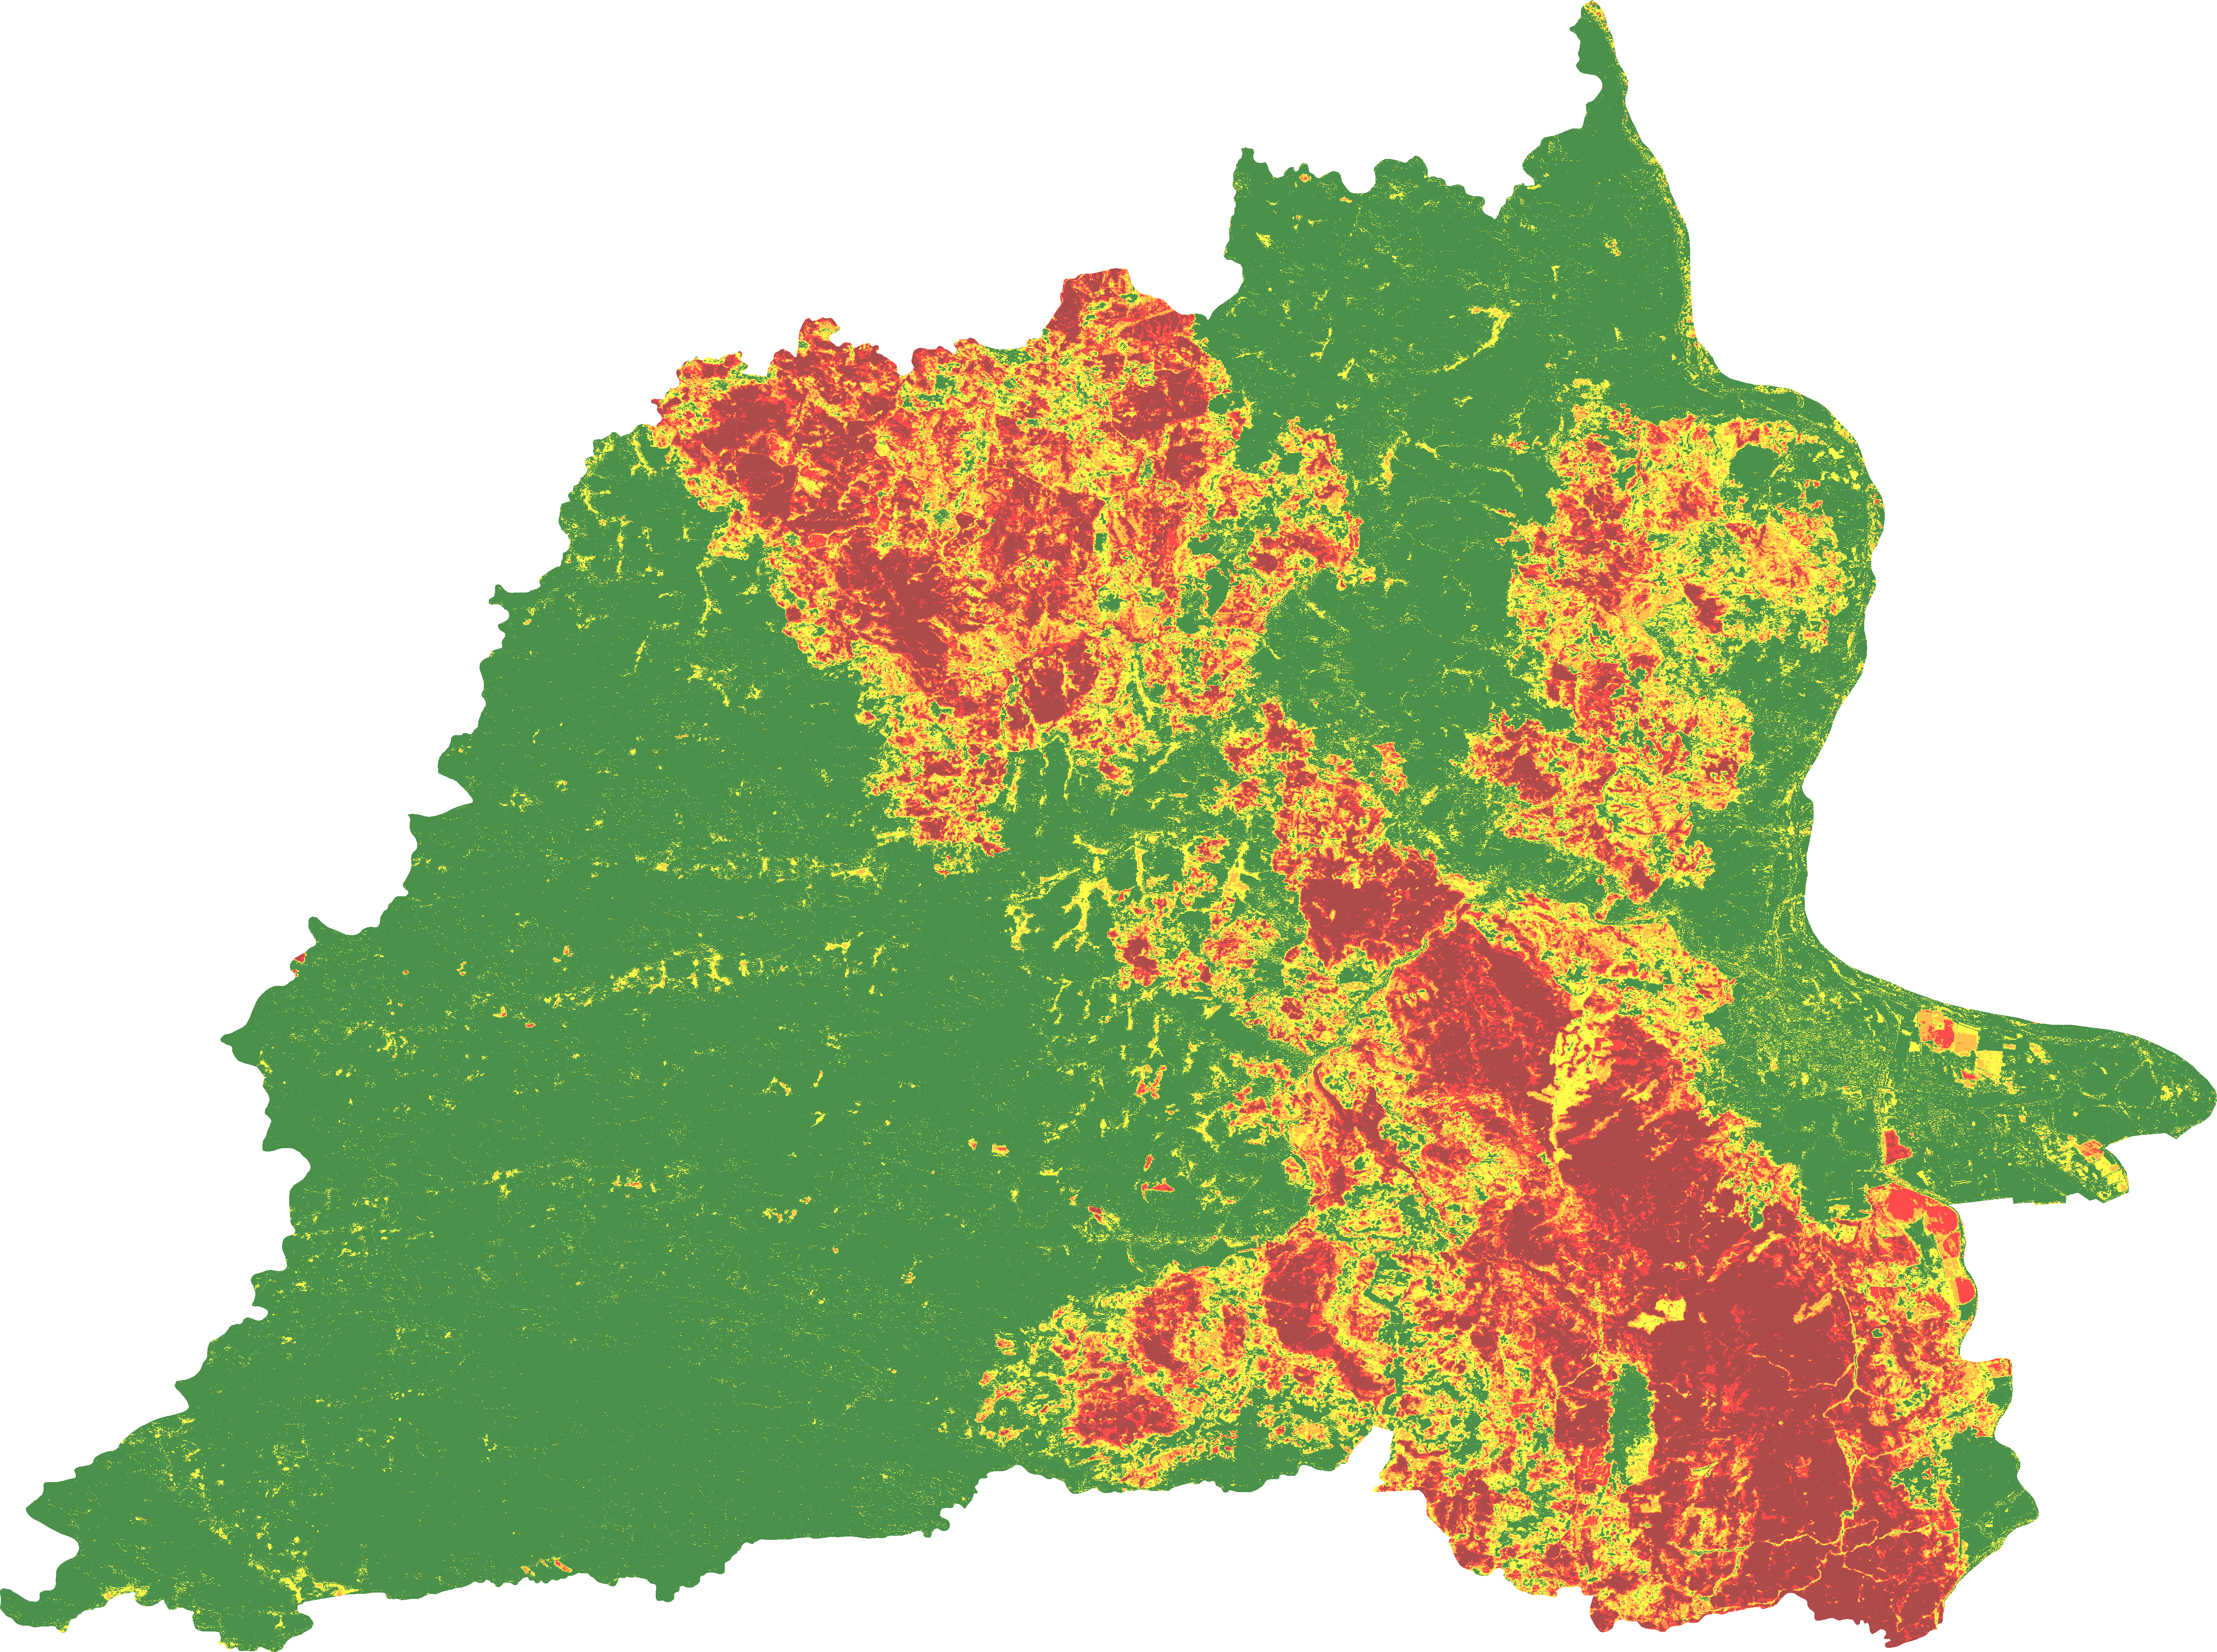

In [26]:
import folium

# Calculate center point for the map
center_lat = (bounds.bottom + bounds.top) / 2
center_lon = (bounds.left + bounds.right) / 2

# Base map with Esri satellite imagery
m = folium.Map(location=[center_lat, center_lon], zoom_start=11, tiles=None)

folium.TileLayer(
    tiles='https://server.arcgisonline.com/ArcGIS/rest/services/World_Imagery/MapServer/tile/{z}/{y}/{x}',
    attr='Esri',
    name='Satellite'
).add_to(m)

folium.TileLayer(
    tiles='https://{s}.basemaps.cartocdn.com/light_only_labels/{z}/{x}/{y}{r}.png',
    attr='CartoDB',
    name='Labels',
    overlay=True
).add_to(m)

# Add the severity classification as an image overlay
folium.raster_layers.ImageOverlay(
    image=rgba,
    bounds=[[bounds.bottom, bounds.left], [bounds.top, bounds.right]],
    name='Burn Severity',
    opacity=0.8
).add_to(m)

folium.LayerControl(collapsed=False).add_to(m)

# Add HTML legend
legend_html = '''
<div style="position: fixed; 
            bottom: 30px; left: 30px; width: 200px; 
            background-color: white; z-index:9999; font-size:13px;
            border:2px solid grey; border-radius:6px; padding: 10px;
            font-family: Arial, sans-serif;">
<b>Burn Severity</b><br>
<i style="background:darkgreen; width:15px; height:15px; float:left; margin-right:8px; opacity:0.8;"></i>Unburned / Regrowth<br>
<i style="background:yellow; width:15px; height:15px; float:left; margin-right:8px; opacity:0.8;"></i>Low Severity<br>
<i style="background:orange; width:15px; height:15px; float:left; margin-right:8px; opacity:0.8;"></i>Moderate-Low Severity<br>
<i style="background:red; width:15px; height:15px; float:left; margin-right:8px; opacity:0.8;"></i>Moderate-High Severity<br>
<i style="background:darkred; width:15px; height:15px; float:left; margin-right:8px; opacity:0.8;"></i>High Severity<br>
</div>
'''

m.get_root().html.add_child(folium.Element(legend_html))

# Save as standalone HTML file
m.save('../outputs/nacimiento_burn_severity_map.html')
print("Map saved successfully.")

m

## 8. Conclusions

This analysis mapped burn severity for the February 2023 "Santa Ana" wildfire within Nacimiento commune using Sentinel-2 dNBR classification (USGS thresholds).

**Key results:**
- Total area analyzed: 90,993.7 ha (full Nacimiento commune, GADM boundary)
- Area with detectable burn severity (low to high): ~36,251 ha (39.8% of the commune)
- High severity: 10,708.8 ha (11.8%)
- Moderate-high severity: 7,652.0 ha (8.4%)
- Moderate-low severity: 7,799.6 ha (8.6%)
- Low severity: 10,090.8 ha (11.1%)

**Spatial pattern:** Burn severity is concentrated in a diagonal band crossing the commune from northwest to southeast, consistent with the reported fire spread direction from Nacimiento toward Santa Juana.

**Methodological note:** This dNBR-based estimate (39.8% of communal area affected) differs from press-reported figures (~75% of Nacimiento affected). This discrepancy likely reflects differences in measurement approach: dNBR captures spectrally detectable vegetation loss, while official perimeter-based figures may include total area within fire combat/containment lines, which can extend beyond zones with measurable vegetation impact. Early vegetation regrowth by the April 2023 post-fire image date may also have reduced detectable severity in some previously low-intensity burn areas.

**Data sources:** Sentinel-2 Surface Reflectance (Copernicus/S2_SR_HARMONIZED), GADM administrative boundaries.

**Tools:** Google Earth Engine (Python API), geemap, rasterio, Folium.